In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import spsolve
import sys, os
# make sure scripts/theory is importable when the notebook runs from the repo root
sys.path.insert(0, os.path.abspath('scripts/theory'))
from utils import (solve_committor_upwind, q_func_factory, weighted_diffusion_system, build_symbolic_helpers)
from ase import units
# ready: functions are imported from scripts/theory/utils.py

In [12]:
# Exemple: construire helpers symboliques pour un potentiel choisi
# Définit D et theta, puis affiche les expressions symboliques
gamma_trap = 0

D = ['(x**2-1)**2', 'y**2', 'exp(-30*(x**2 + y**2))']
theta = np.array([1.0, 1.0, -gamma_trap])
theta_len = len(theta)
temperature_K = 5000
beta = 1 / (units.kB * temperature_K)
gamma = 0.01* units.fs
# beta = 1
helpers = build_symbolic_helpers(D, theta_len=theta_len)
print('V_sym =', helpers['V_sym'])
print('Vx_sym =', helpers['Vx_sym'])
print('Vy_sym =', helpers['Vy_sym'])
print('lapD_syms =', helpers['lapD_syms'])
# Les fonctions numériques sont disponibles: D_func, gradV_func, etc

V_sym = theta0*(x**2 - 1)**2 + theta1*y**2 + theta2*exp(-30*x**2 - 30*y**2)
Vx_sym = 4*theta0*x*(x**2 - 1) - 60*theta2*x*exp(-30*x**2 - 30*y**2)
Vy_sym = 2*theta1*y - 60*theta2*y*exp(-30*x**2 - 30*y**2)
lapD_syms = [4*(3*x**2 - 1), 2, 60*(60*x**2 - 1)*exp(-30*x**2 - 30*y**2) + 60*(60*y**2 - 1)*exp(-30*x**2 - 30*y**2)]


In [13]:
gradV = helpers['gradV_func']

q_min=0.000000, q_max=1.000000


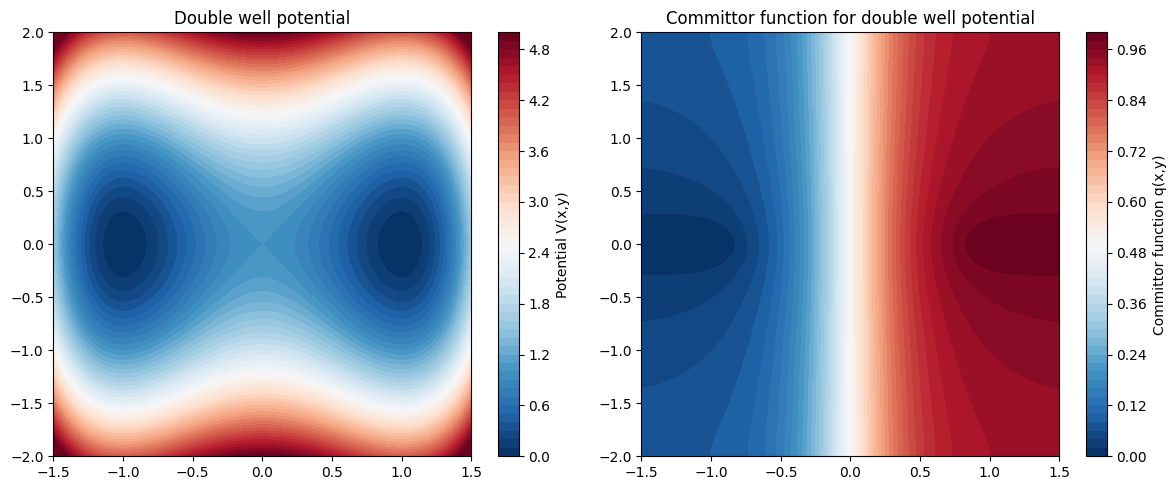

In [14]:
x_min, x_max = -1.5, 1.5
y_min, y_max = -2.0, 2.0
dx = 0.01
dy = 0.01
discretisation = int((x_max - x_min) / dx) + 1


q = solve_committor_upwind(discretisation, discretisation, (x_min, x_max), (y_min, y_max), theta, gradV, beta=beta,gamma = gamma)
print(f"q_min={q.min():.6f}, q_max={q.max():.6f}")
X, Y = np.meshgrid(np.linspace(x_min, x_max, discretisation), np.linspace(y_min, y_max, discretisation), indexing='ij')

V = helpers['V_func'](X, Y, theta)
#plot with clipping values of V
V_clipped = np.clip(V, 0, 5)  # Adjust the clipping values as needed
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].contourf(X, Y, V_clipped, levels=50, cmap='RdBu_r')
fig.colorbar(im0, ax=axes[0], label='Potential V(x,y)')

axes[0].set_title('Double well potential')
im1 = axes[1].contourf(X, Y, q, levels=50, cmap='RdBu_r')
fig.colorbar(im1, ax=axes[1], label='Committor function q(x,y)')
axes[1].set_title('Committor function for double well potential')
plt.tight_layout()


In [15]:
# use q_func_factory and imported g/M
q_func = q_func_factory(x_min, y_min, dx, dy, q)
# example usage: M((0.2,0.1), q_func, beta=beta, theta=theta)
q_func(-0.8, 0)

np.float64(0.061709955050584554)

In [16]:
# Compute u_k solving div(M grad u_k) = -beta M g_k for each component k
x = np.linspace(x_min, x_max, discretisation)
y = np.linspace(y_min, y_max, discretisation)
X, Y = np.meshgrid(x, y, indexing='ij')
radius_P = 0.1
mask_P = np.sqrt((X - 1.0)**2 + Y**2) <= radius_P
eps_q = 1e-12
q_pos = np.clip(q, eps_q, 1.0)
V_field = helpers['V_func'](X, Y, theta)
M_field = np.exp(-beta * V_field) * (q_pos**2)

# Build g component-wise: g_k = 0.5 * Lap(D_k) - 0.5 * beta * <grad D_k, grad V>
gradVx, gradVy = helpers['gradV_func'](X, Y, theta)
gradV_field = np.stack([gradVx, gradVy], axis=-1)
gradD_field = helpers['gradientD_func'](X, Y)
lapD_field = helpers['laplacianD_func'](X, Y)
g_field = 0.5 * lapD_field - 0.5 * beta * np.sum(gradD_field * gradV_field[:, :, None, :], axis=-1)

A_u_base, rhs_u_base = weighted_diffusion_system(M_field, mask_P, dx, dy)
nx, ny = discretisation, discretisation
interior_mask = ~(mask_P | (X == x_min) | (X == x_max) | (Y == y_min) | (Y == y_max))
u = np.zeros((nx, ny, theta_len))

for k in range(theta_len):
    A_u = A_u_base.tolil()
    rhs_u = rhs_u_base.copy()
    source_u = -beta * (M_field * g_field[:, :, k])
    rhs_u[interior_mask.ravel()] += source_u.ravel()[interior_mask.ravel()]
    u[:, :, k] = spsolve(A_u.tocsr(), rhs_u).reshape((nx, ny))

# Solve for w_k: div(M grad w_k) = -2 beta M g_k u_k for each component k
A_w_base, rhs_w_base = weighted_diffusion_system(M_field, mask_P, dx, dy)
w = np.zeros_like(u)

for k in range(theta_len):
    A_w = A_w_base.tolil()
    rhs_w = rhs_w_base.copy()
    source_w = -2.0 * beta * (M_field * g_field[:, :, k] * u[:, :, k])
    rhs_w[interior_mask.ravel()] += source_w.ravel()[interior_mask.ravel()]
    w[:, :, k] = spsolve(A_w.tocsr(), rhs_w).reshape((discretisation, discretisation))


In [ ]:
# Temps moyen de reaction conditionne: L* T = -1
# Forme divergence: div(M grad T) = -beta M, avec T=0 sur dP et flux nul au bord externe.
A_T_base, rhs_T_base = weighted_diffusion_system(M_field, mask_P, dx, dy)
rhs_T = rhs_T_base.copy()
source_T = -beta * M_field
rhs_T[interior_mask.ravel()] += source_T.ravel()[interior_mask.ravel()]
T_reactive = spsolve(A_T_base, rhs_T).reshape((discretisation, discretisation))

# Second moment: L* tau2 = -2 T  <=>  div(M grad tau2) = -2 beta M T
A_tau2_base, rhs_tau2_base = weighted_diffusion_system(M_field, mask_P, dx, dy)
rhs_tau2 = rhs_tau2_base.copy()
source_tau2 = -2.0 * beta * (M_field * T_reactive)
rhs_tau2[interior_mask.ravel()] += source_tau2.ravel()[interior_mask.ravel()]
tau2_reactive = spsolve(A_tau2_base, rhs_tau2).reshape((discretisation, discretisation))

Var_T_reactive = np.maximum(tau2_reactive - T_reactive**2, 0.0)

# Meme condition initiale que plus bas
x0 = (-0.8, 0.0)
i0 = int((x0[0] - x_min) / dx)
j0 = int((x0[1] - y_min) / dy)
i0 = np.clip(i0, 0, discretisation - 1)
j0 = np.clip(j0, 0, discretisation - 1)

print(f"T(x0) = E*[tau | x0={x0}] = {T_reactive[i0, j0]:.6f}")
print(f"E*[tau^2 | x0={x0}] = {tau2_reactive[i0, j0]:.6f}")
print(f"Var*[tau | x0={x0}] = {Var_T_reactive[i0, j0]:.6f}")

fig, ax = plt.subplots()
im0 = ax.contourf(X, Y, T_reactive, levels=50, cmap='viridis')
fig.colorbar(im0, ax=ax, label='T(x,y)')
ax.set_title('Temps moyen reactif T')


In [ ]:
# Cellule 8: estimer D sur la frontiere de P et calculer E[a_k], Var[a_k] composante par composante
D_vals = helpers['D_func'](X, Y)
if np.any(mask_P):
    D_on_boundary_mean = D_vals[mask_P].mean(axis=0)
else:
    D_on_boundary_mean = D_vals.mean(axis=(0, 1))

# Choose an initial point x0 (here center), and map to nearest grid index
x0 = (-0.8, 0.0)
i0 = int((x0[0] - x_min) / dx)
j0 = int((x0[1] - y_min) / dy)
i0 = np.clip(i0, 0, discretisation - 1)
j0 = np.clip(j0, 0, discretisation - 1)

D_x0 = helpers['D_func'](np.array([[x0[0]]]), np.array([[x0[1]]]))[0, 0, :]
u_x0 = u[i0, j0, :]
w_x0 = w[i0, j0, :]

E_a = 0.5 * beta * (D_x0 - D_on_boundary_mean) + u_x0
Var_a = w_x0 - u_x0**2

print('D_on_boundary_mean =', D_on_boundary_mean)
print('D_x0 =', D_x0)
print('u(x0) by component =', u_x0)
print('w(x0) by component =', w_x0)
print('E[a] by component =', E_a)
print('Var[a] by component =', Var_a)
print('probability of transition (q at x0) =', q_func(x0[0], x0[1]))

D_on_boundary_mean = [9.73767464e-03 2.55394799e-03 1.41922731e-12]
D_x0 = [1.29600000e-01 0.00000000e+00 4.58718175e-09]
u(x0) by component = [-5.31461847 -1.15673959 -1.1003551 ]
w(x0) by component = [33.74867246  3.37523828  7.76622119]
E[a] by component = [-4.96688222 -1.16414893 -1.10035509]
Var[a] by component = [5.50350301 2.03719179 6.55543985]
probability of transition (q at x0) = 0.0033366076083990647


In [ ]:
n_rep_by_component = Var_a**2
print('n_rep by component =', n_rep_by_component)

n_rep by component = [30.28854543  4.1501504  42.97379161]
